# Abbildungen zur Modellauswahl (Kapitel 5.6)

| Datei | Abbildung | Aussage |
|---|---|---|
| `modellauswahl_rho_je_dimension.*` | ρ je Dimension und Modell (n=50, alle Kandidaten) | Die Modellwahl berührt nur **eine** der vier Dimensionen; die drei deterministischen sind über alle Modelle identisch. |
| `modellauswahl_wiederholungen.*` | ρ Aussagekraft je Modell mit Wiederholungsspanne (n=30) | Ob ein Abstand zwischen Modellen größer ist als die Schwankung desselben Modells zwischen Läufen. |

**Zur zweiten Abbildung — zwei bewusste Designentscheidungen.**

*Kein Referenzmodell.* Eine frühere Fassung zeichnete ein Streuungsband um *ein*
ausgewähltes Modell und beschriftete die anderen als „innerhalb/außerhalb". Das ist ein
Framing-Artefakt: Zentriert man dasselbe Band um ein anderes Modell, kehrt sich die
Aussage um. Wer im Zentrum steht, wird zur Norm, an der alle anderen gemessen werden —
die Grafik beantwortet dann „weicht jemand von X ab?" statt „wie verhalten sich die
Kandidaten zueinander?". Jetzt trägt jedes Modell seine eigene Spanne.

*Nur Modelle mit Wiederholungen.* Die Abbildung vergleicht Streuungen. Ein Modell mit
einem einzigen Lauf hat keine, und ein Einzelpunkt neben zwei Spannen suggeriert eine
Präzision, die nicht belegt ist. Solche Modelle werden ausgeblendet
(`ABB2_NUR_MIT_WIEDERHOLUNGEN`); in Abbildung 1, wo es um den Dimensionsvergleich geht,
sind weiterhin alle Kandidaten enthalten.

Alle Werte der zweiten Abbildung liegen auf **derselben Teilstichprobe (n=30)**, weil nur
dort Wiederholungen vorliegen. Die n=50-Werte aus Abbildung 1 und der Kennzahlentabelle
sind davon getrennt zu halten — Spannen und Einzelwerte unterschiedlicher Stichproben
dürfen nicht in einer Grafik gemischt werden.

In [1]:
# ---------------------------------------------------------------------------
# EINGABE
# ---------------------------------------------------------------------------
# Ground-Truth-Auswertungen je Modell (Ordner aus Notebook 10, Basis n=50).
MODELL_GT = {
    "GPT-5.5":    "outputs/ground_truth/2026-07-16_11-38-35_figures_gpt5_5",
    "Opus 4.8":   "outputs/ground_truth/2026-07-16_14-43-40_figures_opus4_8",
    "Sonnet 4.6": "outputs/ground_truth/2026-07-16_14-44-19_figures_sonnet4_6",
}

# Wiederholungslaeufe je Modell. Ein Modell darf auch nur einen Lauf haben -
# es taucht dann in Abbildung 2 nur auf, wenn ABB2_NUR_MIT_WIEDERHOLUNGEN=False.
WIEDERHOLUNGEN = {
    "GPT-5.5": [
        "outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5",
        "outputs/runs/run_2026-07-20_11-43-12_state-evaluation-final_EVAL_gpt5-5",
        "outputs/runs/run_2026-07-20_11-55-49_state-evaluation-final_EVAL_gpt5-5",
    ],
    "Opus 4.8": [
        "outputs/runs/run_2026-07-16_11-51-42_state-evaluation-final_EVAL_opus4-8",
    ],
    "Sonnet 4.6": [
        "outputs/runs/run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6",
        "outputs/runs/run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6",
        "outputs/runs/run_2026-07-20_09-01-17_state-evaluation-final_EVAL_sonnet4-6",
    ],
}

# Abbildung 2 vergleicht Wiederholungsspannen. Modelle mit nur einem Lauf haben
# keine Spanne; ein Einzelpunkt daneben suggeriert eine Praezision, die nicht
# belegt ist. Sie werden deshalb ausgeblendet. Auf False setzen, um sie als
# gekennzeichneten Einzellauf mitzuzeichnen.
# (Abbildung 1 zeigt weiterhin alle Kandidaten - dort geht es um den
# Dimensionsvergleich, nicht um Wiederholbarkeit.)
ABB2_NUR_MIT_WIEDERHOLUNGEN = True

# Teilstichprobe, auf der alle Laeufe vergleichbar sind (auch die 50-Datei-Laeufe
# enthalten diese Dateien, werden also auf denselben Teilsatz reduziert).
DATEI_FILTER = r"_0[234]\.rdf$"

GT_CSV = "data/sample_2026-06-25_09-57/ground_truth_template_slim.csv"
AUSGABE_ORDNER = "outputs/model_comparison/plots"

In [2]:
import json
import re
import statistics as st
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

REPO_ROOT = Path.cwd().parents[1]
sys.path.insert(0, str(REPO_ROOT / "src"))

from evaluation.ground_truth import (  # noqa: E402
    load_ground_truth, load_model_scores, merge_scores, spearman,
)

out_dir = REPO_ROOT / AUSGABE_ORDNER
out_dir.mkdir(parents=True, exist_ok=True)

DIMS = ["findability", "accessibility", "reusability", "expressiveness"]
DIM_DE = {"findability": "Auffindbarkeit", "accessibility": "Zugänglichkeit",
          "reusability": "Wiederverwendbarkeit", "expressiveness": "Aussagekraft"}
LLM_DIM = "expressiveness"   # einzige LLM-gestuetzte Dimension

modelle = list(MODELL_GT)

# --- Basis n=50: rho je Dimension aus den Kennzahlen-JSONs ------------------
rho50 = {}
for m, d in MODELL_GT.items():
    j = json.loads((REPO_ROOT / d / "eval_kennzahlen.json").read_text(encoding="utf-8"))
    rho50[m] = {dim: float(j["pro_dimension"][dim]["spearman"]) for dim in DIMS}

print("rho je Dimension (n=50)")
print(f"{'Dimension':<22}" + "".join(f"{m:>13}" for m in modelle))
for dim in DIMS:
    kennzeichen = "   <- LLM" if dim == LLM_DIM else "   (deterministisch)"
    print(f"{DIM_DE[dim]:<22}" + "".join(f"{rho50[m][dim]:>13.4f}" for m in modelle) + kennzeichen)

rho je Dimension (n=50)
Dimension                   GPT-5.5     Opus 4.8   Sonnet 4.6
Auffindbarkeit               0.5244       0.5244       0.5244   (deterministisch)
Zugänglichkeit               0.7119       0.7119       0.7119   (deterministisch)
Wiederverwendbarkeit         0.7390       0.7390       0.7390   (deterministisch)
Aussagekraft                 0.5687       0.6084       0.5981   <- LLM


In [3]:
# --- Basis n=30: rho der Aussagekraft je einzelnem Lauf ---------------------
gt = load_ground_truth(REPO_ROOT / GT_CSV)
muster = re.compile(DATEI_FILTER)


def rho_lauf(run: str) -> float:
    df = merge_scores(gt, load_model_scores(REPO_ROOT / run))
    # Gefiltert wird ueber die Spalte "file"; der Index ist ein RangeIndex.
    teil = df[df["file"].astype(str).str.contains(muster)]
    if teil.empty:
        raise ValueError(f"DATEI_FILTER trifft keine Zeile in {run}")
    return float(spearman(teil[f"model_{LLM_DIM}"], teil[f"gt_{LLM_DIM}"]))


rho30 = {m: [rho_lauf(r) for r in runs] for m, runs in WIEDERHOLUNGEN.items()}

print("rho Aussagekraft je Lauf (n=30)")
print(f"{'Modell':<12}{'Läufe':>7}{'Mittel':>9}{'Min':>9}{'Max':>9}{'Spanne':>9}{'sigma':>9}")
for m in modelle:
    v = rho30[m]
    s = f"{st.stdev(v):>9.4f}" if len(v) > 1 else f"{'—':>9}"
    sp = f"{max(v) - min(v):>9.4f}" if len(v) > 1 else f"{'—':>9}"
    print(f"{m:<12}{len(v):>7}{st.mean(v):>9.4f}{min(v):>9.4f}{max(v):>9.4f}{sp}{s}")

# Streuung ist hier eine Eigenschaft der Aufgabe, nicht des Modells: Wo mehrere
# Laeufe vorliegen, sind die sigma nahezu gleich. Der gepoolte Wert dient als
# Massstab dafuer, ab wann ein Modellabstand ueberhaupt interpretierbar ist.
mit_wdh = [m for m in modelle if len(rho30[m]) > 1]
sigma_pool = (sum(st.stdev(rho30[m]) ** 2 for m in mit_wdh) / len(mit_wdh)) ** 0.5 if mit_wdh else float("nan")
print(f"\ngepoolte sigma über {len(mit_wdh)} Modelle mit Wiederholungen: {sigma_pool:.4f}")

for a, b in [(x, y) for i, x in enumerate(mit_wdh) for y in mit_wdh[i + 1:]]:
    diff = st.mean(rho30[a]) - st.mean(rho30[b])
    se = (st.stdev(rho30[a]) ** 2 / len(rho30[a]) + st.stdev(rho30[b]) ** 2 / len(rho30[b])) ** 0.5
    ueberlappt = min(rho30[a]) <= max(rho30[b]) and min(rho30[b]) <= max(rho30[a])
    print(f"  {a} − {b}: Δ = {diff:+.4f} ({abs(diff)/sigma_pool:.1f}× gepoolte sigma, "
          f"SE = {se:.4f}) | Wertebereiche überlappen: {'ja' if ueberlappt else 'nein'}")

loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_11-43-12_state-evaluation-final_EVAL_gpt5-5
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_11-55-49_state-evaluation-final_EVAL_gpt5-5
loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_11-51-42_state-evaluation-final_EVAL_opus4-8
loaded 50 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/outputs/runs/run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6
loaded 30 scored files from /home/lbuerger/masterthesis/master_thesis_prototype/o

In [4]:
# Palette: kategoriale Slots, mit scripts/validate_palette.js geprueft.
# Wertelabels an jeder Markierung liefern die zweite Kodierungsebene neben der Farbe.
FARBEN = {"GPT-5.5": "#2a78d6", "Opus 4.8": "#008300", "Sonnet 4.6": "#e87ba4"}
TEXT, TEXT_SEK, GRID = "#0b0b0b", "#52514e", "#d8d7d2"


def stil(ax):
    for r in ("top", "right"):
        ax.spines[r].set_visible(False)
    for r in ("left", "bottom"):
        ax.spines[r].set_color(GRID)
    ax.tick_params(colors=TEXT_SEK, labelsize=9)


def speichern(fig, name):
    """PNG fuer die Vorschau, PDF als Vektor fuer LaTeX."""
    for endung in ("png", "pdf"):
        p = out_dir / f"{name}.{endung}"
        fig.savefig(p, dpi=200, bbox_inches="tight", facecolor="white", edgecolor="none")
        print(f"geschrieben: {p.relative_to(REPO_ROOT)}")

geschrieben: outputs/model_comparison/plots/modellauswahl_rho_je_dimension.png
geschrieben: outputs/model_comparison/plots/modellauswahl_rho_je_dimension.pdf


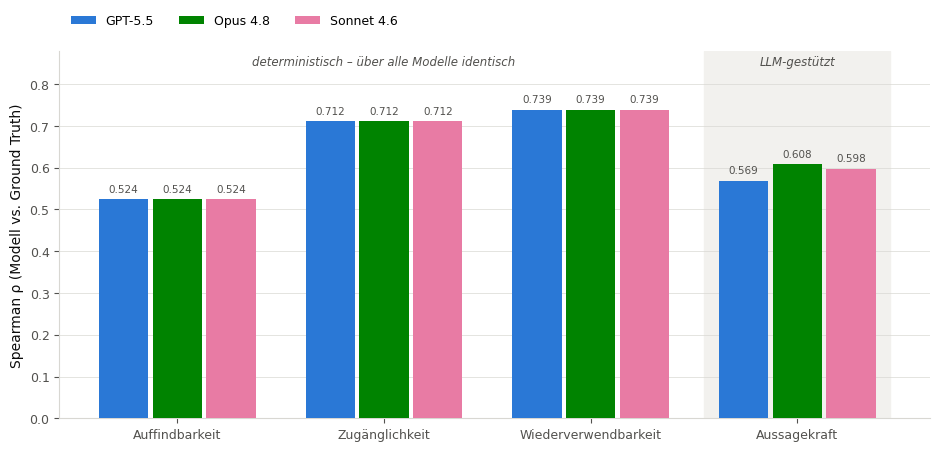

In [5]:
# --- Abbildung 1: rho je Dimension und Modell (n=50) ------------------------
fig, ax = plt.subplots(figsize=(9.5, 4.6))
x, breite = np.arange(len(DIMS)), 0.26
i_llm = DIMS.index(LLM_DIM)
ax.axvspan(i_llm - 0.45, i_llm + 0.45, color="#f2f1ee", zorder=0)

for k, m in enumerate(modelle):
    werte = [rho50[m][d] for d in DIMS]
    balken = ax.bar(x + (k - 1) * breite, werte, breite * 0.92, label=m,
                    color=FARBEN[m], zorder=3)
    for b, w in zip(balken, werte):
        ax.text(b.get_x() + b.get_width() / 2, w + 0.012, f"{w:.3f}", ha="center",
                va="bottom", fontsize=7.5, color=TEXT_SEK, zorder=4)

ax.set_ylabel("Spearman ρ (Modell vs. Ground Truth)", fontsize=10, color=TEXT)
ax.set_ylim(0, 0.88)
ax.set_xticks(x)
ax.set_xticklabels([DIM_DE[d] for d in DIMS], fontsize=10, color=TEXT)
ax.set_axisbelow(True)
ax.grid(axis="y", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)
ax.annotate("deterministisch – über alle Modelle identisch", xy=(1.0, 0.845),
            ha="center", fontsize=8.5, color=TEXT_SEK, style="italic")
ax.annotate("LLM-gestützt", xy=(i_llm, 0.845), ha="center", fontsize=8.5,
            color=TEXT_SEK, style="italic")
ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper left", bbox_to_anchor=(0.0, 1.13))

fig.tight_layout()
speichern(fig, "modellauswahl_rho_je_dimension")
plt.show()

ohne Wiederholungen, daher nicht in Abbildung 2: Opus 4.8 (1 Lauf)
geschrieben: outputs/model_comparison/plots/modellauswahl_wiederholungen.png
geschrieben: outputs/model_comparison/plots/modellauswahl_wiederholungen.pdf


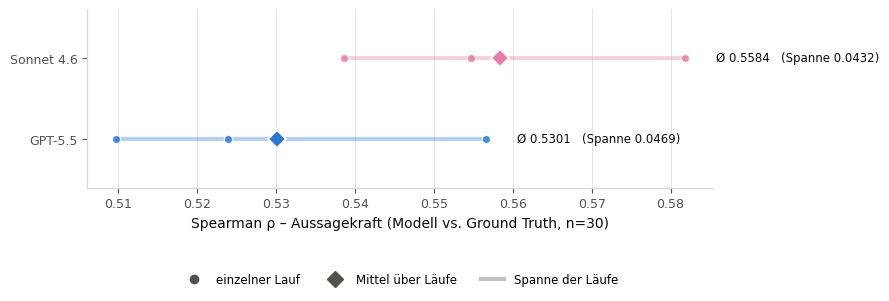

In [6]:
# --- Abbildung 2: Wiederholungen je Modell (n=30) --------------------------
# Neutral: jedes Modell mit der eigenen Spanne, kein Referenzmodell, keine
# Vorwegnahme der Entscheidung.
gezeigt = [m for m in modelle
           if not ABB2_NUR_MIT_WIEDERHOLUNGEN or len(rho30[m]) > 1]
ausgeblendet = [m for m in modelle if m not in gezeigt]
if ausgeblendet:
    print("ohne Wiederholungen, daher nicht in Abbildung 2: "
          + ", ".join(f"{m} ({len(rho30[m])} Lauf)" for m in ausgeblendet))

sortiert = sorted(gezeigt, key=lambda m: st.mean(rho30[m]))
# Hoehe waechst mit der Zeilenzahl, damit die Abstaende gleich bleiben.
fig, ax = plt.subplots(figsize=(9.0, 1.05 * len(sortiert) + 1.4))

for i, m in enumerate(sortiert):
    v = rho30[m]
    mittel = st.mean(v)
    if len(v) > 1:
        ax.hlines(i, min(v), max(v), color=FARBEN[m], linewidth=3, alpha=0.35, zorder=2)
        ax.plot(v, [i] * len(v), "o", markersize=6, color=FARBEN[m], alpha=0.85,
                markeredgecolor="white", markeredgewidth=1.0, zorder=3)
        ax.plot(mittel, i, "D", markersize=9, color=FARBEN[m], zorder=4,
                markeredgecolor="white", markeredgewidth=1.4)
        ax.text(max(v) + 0.004, i, f"Ø {mittel:.4f}   (Spanne {max(v) - min(v):.4f})",
                va="center", ha="left", fontsize=8.5, color=TEXT, zorder=5)
    else:
        # Hohle Markierung: ein einzelner Lauf, Streuung unbekannt.
        ax.plot(mittel, i, "o", markersize=9, markerfacecolor="white",
                markeredgecolor=FARBEN[m], markeredgewidth=2.0, zorder=4)
        ax.text(mittel + 0.004, i, f"{mittel:.4f}   (nur 1 Lauf, Streuung unbekannt)",
                va="center", ha="left", fontsize=8.5, color=TEXT_SEK, zorder=5)

ax.set_yticks(range(len(sortiert)))
ax.set_yticklabels(sortiert, fontsize=10, color=TEXT)
ax.set_xlabel(f"Spearman ρ – {DIM_DE[LLM_DIM]} (Modell vs. Ground Truth, n=30)",
              fontsize=10, color=TEXT)
ax.set_ylim(-0.6, len(sortiert) - 0.4)
ax.set_axisbelow(True)
ax.grid(axis="x", linestyle="-", linewidth=0.6, color=GRID, alpha=0.8)
stil(ax)

from matplotlib.lines import Line2D  # noqa: E402
handles = [
    Line2D([], [], marker="o", linestyle="none", color=TEXT_SEK, markersize=6,
           label="einzelner Lauf"),
    Line2D([], [], marker="D", linestyle="none", color=TEXT_SEK, markersize=8,
           label="Mittel über Läufe"),
    Line2D([], [], color=TEXT_SEK, linewidth=3, alpha=0.35, label="Spanne der Läufe"),
]
ax.legend(handles=handles, frameon=False, fontsize=8.5, ncol=3,
          loc="upper center", bbox_to_anchor=(0.5, -0.42))

fig.tight_layout()
speichern(fig, "modellauswahl_wiederholungen")
plt.show()

In [7]:
# Zahlen fuer Fliesstext und Bildunterschriften.
print("n=50, ein Lauf je Modell — rho Aussagekraft:")
for m in modelle:
    print(f"  {m:<12} {rho50[m][LLM_DIM]:.4f}")

print("\nn=30, über Wiederholungen — rho Aussagekraft:")
for m in sorted(modelle, key=lambda m: -st.mean(rho30[m])):
    v = rho30[m]
    zusatz = (f"Spanne {max(v) - min(v):.4f}, sigma {st.stdev(v):.4f}"
              if len(v) > 1 else "nur 1 Lauf")
    print(f"  {m:<12} Ø {st.mean(v):.4f}   ({len(v)} Läufe, {zusatz})")

print("\nDeterministische Dimensionen (über alle Modelle identisch):")
for dim in DIMS:
    if dim != LLM_DIM:
        print(f"  ρ {DIM_DE[dim]:<22} = {rho50[modelle[0]][dim]:.4f}")

n=50, ein Lauf je Modell — rho Aussagekraft:
  GPT-5.5      0.5687
  Opus 4.8     0.6084
  Sonnet 4.6   0.5981

n=30, über Wiederholungen — rho Aussagekraft:
  Opus 4.8     Ø 0.5672   (1 Läufe, nur 1 Lauf)
  Sonnet 4.6   Ø 0.5584   (3 Läufe, Spanne 0.0432, sigma 0.0218)
  GPT-5.5      Ø 0.5301   (3 Läufe, Spanne 0.0469, sigma 0.0240)

Deterministische Dimensionen (über alle Modelle identisch):
  ρ Auffindbarkeit         = 0.5244
  ρ Zugänglichkeit         = 0.7119
  ρ Wiederverwendbarkeit   = 0.7390
